<a href="https://colab.research.google.com/github/Nerneri/World_bank_PIP_analysis/blob/Alexandra_branch/Poverty_And_Inequality_Platform_(PIP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Poverty And Inequality Platform Project**

HSE project wiki page : https://wikics.site/Python_Programming_DSBA_2025/26_/_Project

first dataset page. Poverty And Inequality Platform (PIP) : https://datacatalog.worldbank.org/search/dataset/0063646/poverty-and-inequality-platform-pip-percentiles$0

second dataset page. World Bank Country and Lending Groups : https://www.kaggle.com/datasets/taniaj/world-bank-country-and-lending-groups?resource=download$0







In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Mounted at /content/drive
libraries imported successfully


In [3]:
data_path_PIP = '/content/drive/MyDrive/python_project/world_100bin_revised.csv'
data_path_classification = '/content/drive/MyDrive/python_project/worldbank_classification.csv'

data_PIP = pd.read_csv(data_path_PIP)
data_classification = pd.read_csv(data_path_classification)


## **1. Abstract/Annotation**

# **2. Dataset description**

### Poverty And Inequality Platform dataset desciption

In [ ]:
print(f'Rows:    {data_PIP.shape[0]:,}')
print(f'Columns: {data_PIP.shape[1]}')
display(data_PIP.head(10))

Rows:    258,400
Columns: 10


,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop
0,AGO,2000,national,consumption,1,0.285539,0.01,0.000341,0.312285,163108.6019
1,AGO,2000,national,consumption,2,0.405434,0.01,0.000484,0.472927,163108.6019
2,AGO,2000,national,consumption,3,0.554057,0.01,0.000661,0.628385,163108.6019
3,AGO,2000,national,consumption,4,0.692758,0.01,0.000827,0.761937,163108.6019
4,AGO,2000,national,consumption,5,0.809901,0.01,0.000966,0.849781,163108.6019
5,AGO,2000,national,consumption,6,0.918913,0.01,0.001097,0.971565,163108.6019
6,AGO,2000,national,consumption,7,1.022074,0.01,0.001220,1.063902,163108.6019
7,AGO,2000,national,consumption,8,1.102931,0.01,0.001316,1.160249,163108.6019
8,AGO,2000,national,consumption,9,1.212476,0.01,0.001447,1.263488,163108.6019
9,AGO,2000,national,consumption,10,1.300079,0.01,0.001551,1.342370,163108.6019


In [ ]:
data_PIP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258400 entries, 0 to 258399
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   country_code     258400 non-null  object 
 1   year             258400 non-null  int64  
 2   reporting_level  258400 non-null  object 
 3   welfare_type     258400 non-null  object 
 4   percentile       258400 non-null  int64  
 5   avg_welfare      258400 non-null  float64
 6   pop_share        258400 non-null  float64
 7   welfare_share    258400 non-null  float64
 8   quantile         255816 non-null  float64
 9   pop              258400 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 19.7+ MB


There are missing values in quantile (255816, should be 258400).

Moreover, dtype of country_code, reporting_level and welfare_type is object (types of values are mixed).

We will correct this further in 4. Data cleanup.


In [ ]:
print(f"Countries:        {data_PIP['country_code'].nunique()}")
print(f"Year range:       {data_PIP['year'].min()} – {data_PIP['year'].max()}")
print(f"Reporting levels: {data_PIP['reporting_level'].unique()}")
print(f"Welfare types:    {data_PIP['welfare_type'].unique()}")
print(f"Percentiles:      {data_PIP['percentile'].min()} – {data_PIP['percentile'].max()}")

Countries:        172
Year range:       1963 – 2025
Reporting levels: ['national' 'urban' 'rural']
Welfare types:    ['consumption' 'income']
Percentiles:      1 – 100


### World Bank Country and Lending Groups dataset desciption

In [ ]:
print(f'Rows:    {data_classification.shape[0]:,}')
print(f'Columns: {data_classification.shape[1]}')
display(data_classification.head(10))

Rows:    218
Columns: 7


,x,Economy,Code,Region,Income group,Lending category,Other
0,1,Afghanistan,AFG,South Asia,Low income,IDA,HIPC
1,2,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD,NaN
2,3,Algeria,DZA,Middle East & North Africa,Upper middle income,IBRD,NaN
3,4,American Samoa,ASM,East Asia & Pacific,Upper middle income,NaN,NaN
4,5,Andorra,AND,Europe & Central Asia,High income,NaN,NaN
5,6,Angola,AGO,Sub-Saharan Africa,Lower middle income,IBRD,NaN
6,7,Antigua and Barbuda,ATG,Latin America & Caribbean,High income,IBRD,NaN
7,8,Argentina,ARG,Latin America & Caribbean,Upper middle income,IBRD,NaN
8,9,Armenia,ARM,Europe & Central Asia,Upper middle income,IBRD,NaN
9,10,Aruba,ABW,Latin America & Caribbean,High income,NaN,NaN


We can notice that x, Income group and Lending category require renaming, since they do not fit python codestyle or have implicit name.

In [ ]:
data_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   x                 218 non-null    int64 
 1   Economy           218 non-null    object
 2   Code              218 non-null    object
 3   Region            218 non-null    object
 4   Income group      218 non-null    object
 5   Lending category  163 non-null    object
 6   Other             39 non-null     object
dtypes: int64(1), object(6)
memory usage: 12.1+ KB


We have missing values in Lending category and Other.

Moreover, only x (id) have an explicite Dtype

## **3. Data cleanup**

<Axes: >

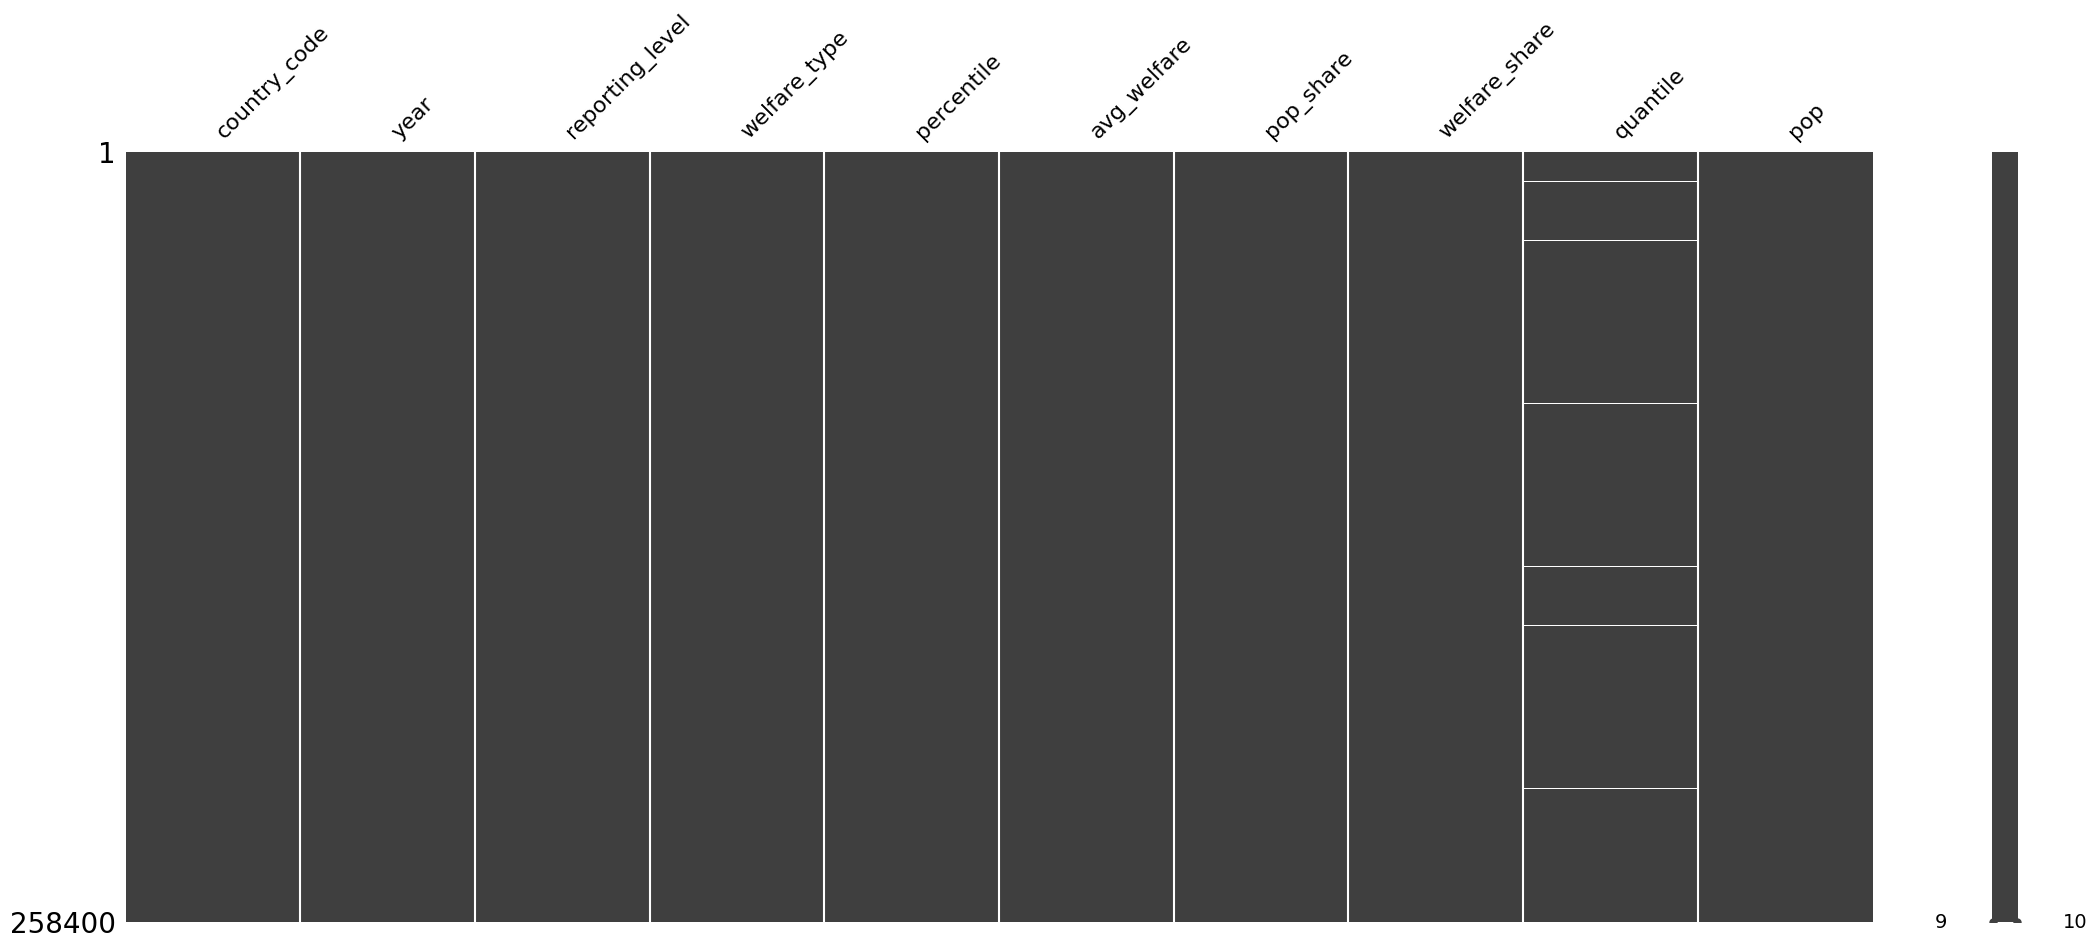

In [4]:
import missingno

missingno.matrix(data_PIP)

Although we could use interpolation for computing missing quantile values, we will choose to ignore those rows, in order to avoid oscillation:

In [17]:
data_PIP = data_PIP.dropna(subset=['quantile']).reset_index(drop=True)
data_PIP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255816 entries, 0 to 255815
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   country_code     255816 non-null  string 
 1   year             255816 non-null  int64  
 2   reporting_level  255816 non-null  string 
 3   welfare_type     255816 non-null  string 
 4   percentile       255816 non-null  int64  
 5   avg_welfare      255816 non-null  float64
 6   pop_share        255816 non-null  float64
 7   welfare_share    255816 non-null  float64
 8   quantile         255816 non-null  float64
 9   pop              255816 non-null  float64
dtypes: float64(5), int64(2), string(3)
memory usage: 19.5 MB


As country_code, reporting_level and welfare_type does not have missing values, we can just forse their dtype into string:

In [6]:
for col in ['country_code', 'reporting_level', 'welfare_type']:
    data_PIP[col] = data_PIP[col].astype('string')

In [7]:
# data_PIP.info()
data_PIP.head()

,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop
0,AGO,2000,national,consumption,1,0.285539,0.01,0.000341,0.312285,163108.6019
1,AGO,2000,national,consumption,2,0.405434,0.01,0.000484,0.472927,163108.6019
2,AGO,2000,national,consumption,3,0.554057,0.01,0.000661,0.628385,163108.6019
3,AGO,2000,national,consumption,4,0.692758,0.01,0.000827,0.761937,163108.6019
4,AGO,2000,national,consumption,5,0.809901,0.01,0.000966,0.849781,163108.6019


<Axes: >

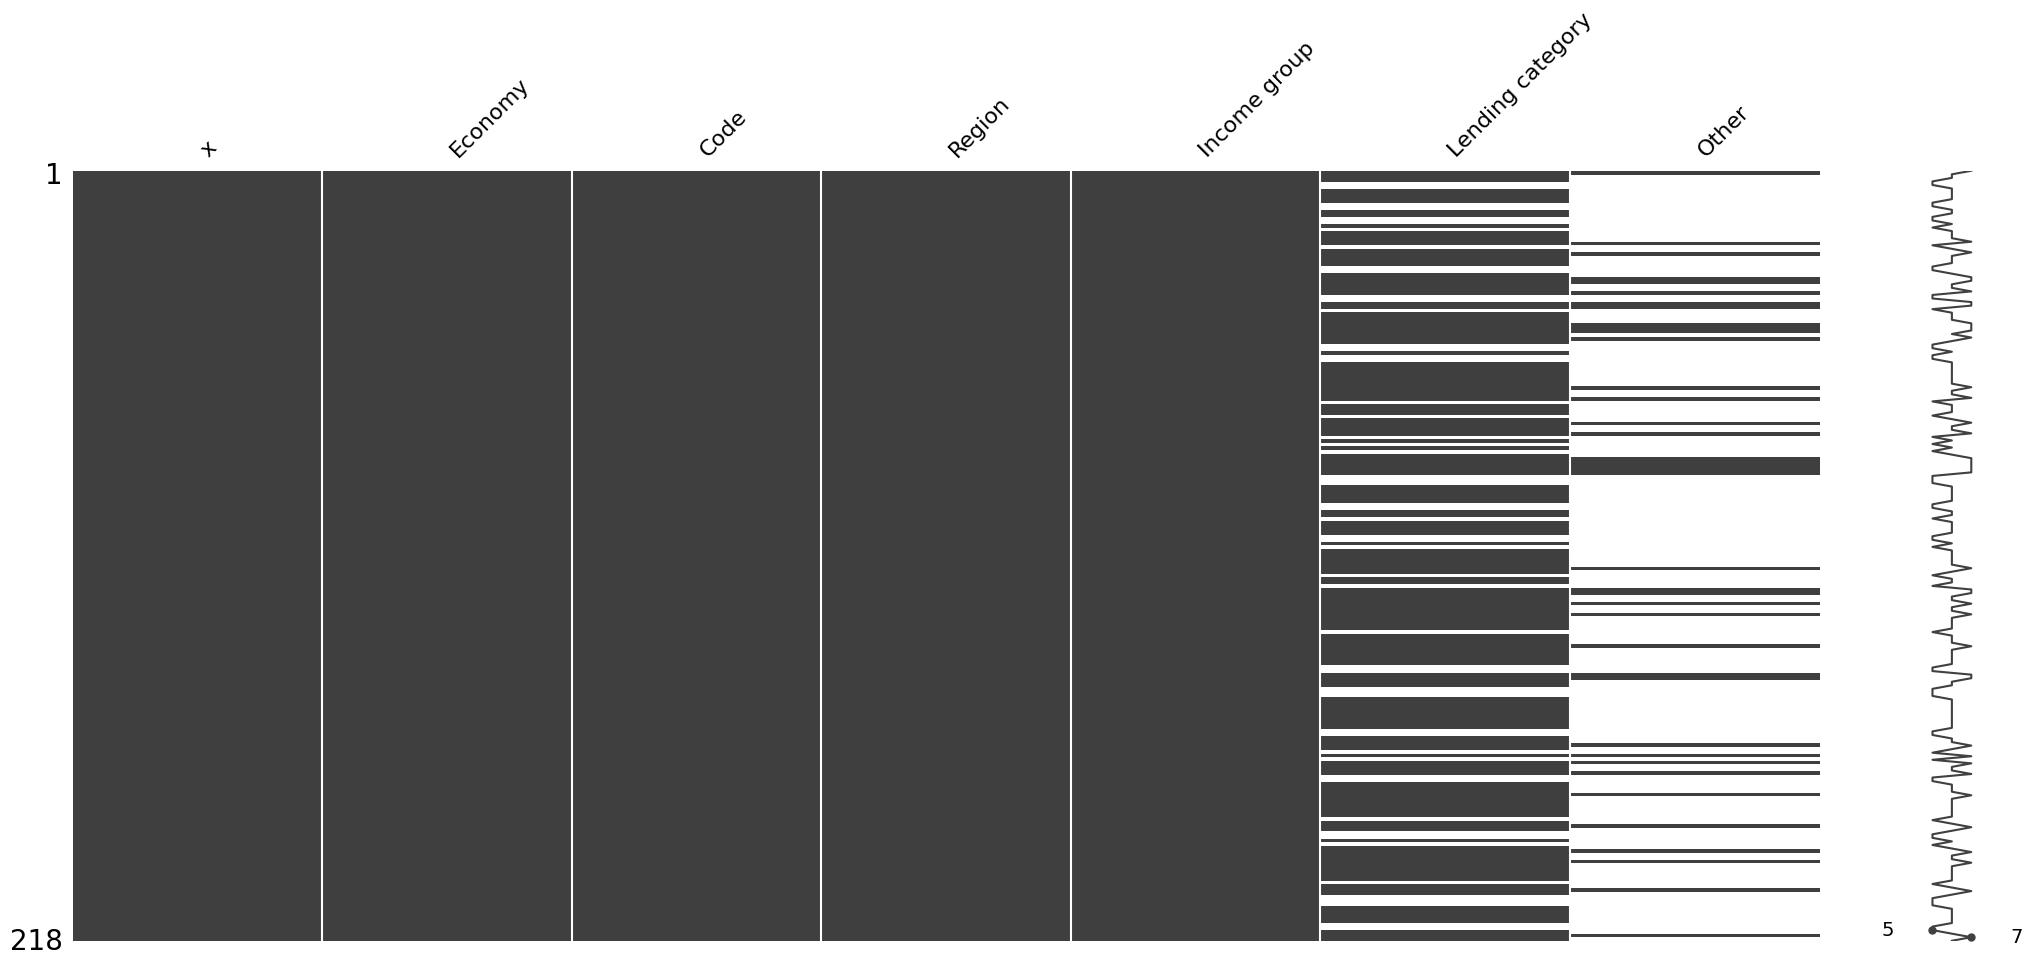

In [8]:
missingno.matrix(data_classification)

Rename columns:

In [9]:
data_classification = data_classification.rename(columns=lambda name: name.lower().replace(' ', '_'))

In [10]:
data_classification.rename(columns={'economy': 'country'}, inplace=True)

In [11]:
for col in ['country', 'code', 'region', 'income_group']:
    data_classification[col] = data_classification[col].astype('string')

In [12]:
data_classification = data_classification.drop(['lending_category', 'other'], axis = 1)

In [13]:
# data_classification.info()
data_classification.head()

,x,country,code,region,income_group
0,1,Afghanistan,AFG,South Asia,Low income
1,2,Albania,ALB,Europe & Central Asia,Upper middle income
2,3,Algeria,DZA,Middle East & North Africa,Upper middle income
3,4,American Samoa,ASM,East Asia & Pacific,Upper middle income
4,5,Andorra,AND,Europe & Central Asia,High income


# *. Creation of new dataset

Now we can create new dataset with regions instead of countries.
We remove dublicate of code and sort it by region

In [14]:
data_PIP_wregion = data_PIP.merge(data_classification, left_on = 'country_code',
                                 right_on = 'code', how='left')
data_PIP_wregion = data_PIP_wregion.drop(['code', 'x'], axis = 1)
data_PIP_wregion = data_PIP_wregion.sort_values('region').reset_index(drop =True)




In [15]:
data_PIP_wregion.head()

,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop,country,region,income_group
0,IDN,2011,national,consumption,32,3.012432,0.01,0.005553,3.034026,2494700.32,Indonesia,East Asia & Pacific,Lower middle income
1,CHN,1984,national,income,86,2.598851,0.01,0.014888,2.625555,10368250.00,China,East Asia & Pacific,Upper middle income
2,CHN,1984,national,income,85,2.547709,0.01,0.014595,2.572726,10368250.00,China,East Asia & Pacific,Upper middle income
3,CHN,1984,national,income,84,2.499602,0.01,0.014320,2.523207,10368250.00,China,East Asia & Pacific,Upper middle income
4,CHN,1984,national,income,83,2.454102,0.01,0.014059,2.476457,10368250.00,China,East Asia & Pacific,Upper middle income


## **5. Descriptive statistics**

In [28]:
NUMERIC = ['avg_welfare', 'pop_share', 'welfare_share', 'pop']
data_PIP_wregion[NUMERIC].describe().round(2)

,avg_welfare,pop_share,welfare_share,pop
count,255816.00,255816.00,255816.00,255816.00
mean,25.65,0.01,0.01,613685.62
std,29.37,0.00,0.01,1658635.46
min,0.28,0.01,0.00,104.40
25%,5.90,0.01,0.01,44842.34
50%,14.59,0.01,0.01,105926.83
75%,35.35,0.01,0.01,474491.23
max,384.83,0.01,0.09,14327581.15


In [30]:
data_PIP_wregion['income_group'].value_counts()

,count
income_group,
High income,109890
Upper middle income,86130
Lower middle income,45342
Low income,14454


In [29]:
data_PIP_wregion['income_group'].value_counts(normalize=True)

,proportion
income_group,
High income,0.429567
Upper middle income,0.336687
Lower middle income,0.177245
Low income,0.056502


In [31]:
data_PIP_wregion[NUMERIC].std().round(2)

,0
avg_welfare,29.37
pop_share,0.00
welfare_share,0.01
pop,1658635.46


In [32]:
data_PIP_wregion[NUMERIC].var().round(2)

,0
avg_welfare,8.628900e+02
pop_share,0.000000e+00
welfare_share,0.000000e+00
pop,2.751072e+12


In [33]:
data_PIP_wregion.groupby('region')[NUMERIC].agg(['mean', 'median', 'std']).round(2)

avg_welfare               pop_share              \
                                  mean median    std      mean median  std   
region                                                                       
East Asia & Pacific              16.34   7.86  21.77      0.01   0.01  0.0   
Europe & Central Asia            34.02  24.45  31.30      0.01   0.01  0.0   
Latin America & Caribbean        15.59  10.17  16.90      0.01   0.01  0.0   
Middle East & North Africa       22.09  12.48  24.60      0.01   0.01  0.0   
North America                    61.21  50.66  42.96      0.01   0.01  0.0   
South Asia                        5.83   4.07   5.45      0.01   0.01  0.0   
Sub-Saharan Africa                4.65   2.93   5.85      0.01   0.01  0.0   

                           welfare_share                      pop              \
                                    mean median   std        mean      median   
region                                                                          
East Asia & Pacific                 0.01   0.01  0.01  2678975.82   796253.97   
Europe & Central Asia               0.01   0.01  0.01   224201.86    84180.29   
Latin America & Caribbean           0.01   0.01  0.01   298853.33    96859.60   
Middle East & North Africa          0.01   0.01  0.01   270301.12    86296.50   
North America                       0.01   0.01  0.01  1645227.90  2063565.00   
South Asia                          0.01   0.01  0.01  2247192.48  1148696.50   
Sub-Saharan Africa                  0.01   0.01  0.01   226232.34   128122.78   

                                        
                                   std  
region                                  
East Asia & Pacific         3852451.99  
Europe & Central Asia        309786.89  
Latin America & Caribbean    484919.45  
Middle East & North Africa   328949.99  
North America               1205912.70  
South Asia                  3539819.53  
Sub-Saharan Africa           338223.13

## **6. Data transofrmation**

In [34]:
bins = pd.IntervalIndex.from_tuples(
    [(0, 1), (1, 5), (5, np.inf)], closed='left'
)
data_PIP_wregion['welfare_category'] = pd.cut(data_PIP_wregion['avg_welfare'], bins)
data_PIP_wregion['welfare_category'] = data_PIP_wregion['welfare_category'].cat.rename_categories(
    ['low', 'medium', 'high']
)

In [35]:
data_PIP_wregion['inequality_ratio'] = data_PIP_wregion['welfare_share'] / data_PIP_wregion['pop_share']

In [36]:
data_PIP_wregion['decade'] = (data_PIP_wregion['year'] // 10) * 10


In [37]:
data_PIP_wregion = data_PIP_wregion.sort_values(['country_code', 'year', 'percentile'])
data_PIP_wregion['welfare_delta'] = data_PIP_wregion.groupby(
    ['country_code', 'year']
)['avg_welfare'].diff().fillna(0)

## **7. Detailed overview**

## **8. Plots**

## **9. Hypothesis check**